In your environment, assuming numpy, matplotlib, and scipy are already installed, run

```bash
pip install mpl-scatter-density
```

Otherwise run,

```bash
conda install numpy matplotlib scipy
pip install mpl-scatter-density
```

In [1]:
import fast_histogram
import numpy as np
from matplotlib.cm import ScalarMappable
from matplotlib.colors import LinearSegmentedColormap, Normalize, LogNorm
import matplotlib.pyplot as plt
import mpl_scatter_density
from scipy.interpolate import interpn

In [1]:
def density_scatter(x: np.ndarray, y: np.ndarray, nbins_x: int, nbins_y: int,
                    fig: plt.Figure, ax: plt.Axes, cax: plt.Axes, log_norm: bool=False,
                    density: bool=True, **kwargs) -> tuple:
    """
    Create a density scatter plot using interpolation and fast histogramming.
    
    Parameters
    ----------
    x : np.ndarray
        Values of x.
    y : np.ndarray
        Values of y.
    nbins_x : int
        The granularity for binning x.
    nbins_y : int
        The granularity for binning y.
    fig : matplotlib.Figure
        Figure containing ax and cax.
    ax : matplotlib.Axes
        The axes on which the scatter will be plotted.
    cax : matplotlib.Axes
        The axes on which the colorbar will be plotted.
    log_norm : bool, default False
        Specifies whether the colobar will display log values.
    density : bool, default True
        Show the density in the colorbar, otherwise show counts.
    **kwargs
        Keywords for plt.scatter.
        
    Returns
    -------
    x_bins : np.ndarray
        The bin edges used for binning x.
    y_bins : np.ndarray
        The bin edges used for binning y.
    """
    # Add an epsilon value to the mins and maxes so the minimal and maximal
    # values are included in the histogram.
    hist_range = [[np.min(x) - 1e-8, np.max(x) + 1e-8],
                  [np.min(y) - 1e-8, np.max(y) + 1e-8]]
    hist_bins = [nbins_x, nbins_y]
    data = fast_histogram.histogram2d(x, y, hist_bins, hist_range)
    x_bins = np.linspace(*hist_range[0], hist_bins[0] + 1)
    y_bins = np.linspace(*hist_range[1], hist_bins[1] + 1)
    
    z = interpn((0.5*(x_bins[1:] + x_bins[:-1]), 0.5*(y_bins[1:]+y_bins[:-1])),
                data , np.vstack([x,y]).T ,
                method = "splinef2d",
                bounds_error = False)

    # z should be nonnegative and not nan since it is the number of counts in a bin.
    z[np.where(np.isnan(z))] = 0.0
    z[z < 0] = 0.0
    
    # Make the highest values of z appear on top.
    idx = z.argsort()
    x, y, z = x[idx], y[idx], z[idx]
    
    if density:
        z /= len(z)

    ax.scatter(x, y, c=z, **kwargs )

    if log_norm:
        norm = LogNorm(vmin = np.min(z[z > 0]), vmax = np.max(z[z > 0]))
    else:
        norm = Normalize(vmin = np.min(z), vmax = np.max(z))
        
    cbar = fig.colorbar(ScalarMappable(norm = norm), cax=cax)
    cbar.ax.set_ylabel('density' if density else 'counts')
    
    return x_bins, y_bins

def joint_plot_grid(in_x: list, in_y: list, nbins_x: int=20, nbins_y: int=20,
                    granularity: int=72, log_norm: bool=False, density: bool=True,
                    xlabels: list=None, ylabels: list=None, label_fontsize: int=None,
                    use_mpl_sd: bool=False, **kwargs) -> None:
    """
    Plot a bunch of joint plots (2-d histogram/scatter density and the x- and y-
    marginals) on a grid.
    
    Parameters
    ----------
    in_x : list of numpy.ndarray or 2-d numpy.ndarray
        Iterable of numpy.ndarrays that will be plotted along the horizontal coordinate.
    in_y : list of numpy.ndarray or 2-d numpy.ndarray
        Iterable of numpy.ndarrays that will be plotted along the vertical coordinate.
    nbins_x : int, default 20
        The granularity for binning x.
    nbins_y : int, default 20
        The granularity for binning y.
    granularity: int, default 72
        The number of dots per inch to include on the density scatter plot.
    log_norm: bool, default False
        Display the colorbar with logarithmic values.
        Does not work for mpl scatter density presently.
    density : bool, default True
        Show the density in the colorbar, otherwise show counts.
        Does not work for mpl scatter density presently.
    xlabels : list of str, optional
        The list of labels for the x-axes.
    ylabels : list of str, optional
        The list of labels for the y-axes.
    labelfontsize : float
        Font size of the labels.
    use_mpl_sd : bool, default False
        Use the scatter density function from mpl_scatter_density.
        This option should result in the plots rendering more quickly
        at the cost of seeing something less like a scatter plot.
    
    Returns
    -------
    None
    """
    if type(in_x) is not list or np.array(in_x).ndim == 1:
        raise RuntimeError('in_x must be a list or be a 2-dimensional numpy array')
    if type(in_y) is not list or np.array(in_y).ndim == 1:
        raise RuntimeError('in_y must be a list or be a 2-dimensional numpy array')
    if len(in_x) != len(in_y):
        raise RuntimeError('There must be the same number of x and y to be plotted.')
    
    if xlabels is not None:
        if len(xlabels) != len(in_x):
            raise RuntimeError('For every x, there must be an x label.')
    if ylabels is not None:
        if len(ylabels) != len(in_y):
            raise RuntimeError('For every y, there must be a y label.')
    if (xlabels is not None and ylabels is None) or (xlabels is None and ylabels is not None):
        raise RuntimeError('Either xlabels and ylabels both need to be supplied '
                           'or neither can be supplied.')
    
    colors = [(0, '#ffffff'), (1e-20, '#440053'), (0.2, '#404388'),
              (0.4, '#2a788e'), (0.6, '#21a784'), (0.8, '#78d151'), (1, '#fde624'),]
    white_viridis = LinearSegmentedColormap.from_list('white_viridis', colors, N=256)

    def make_joint(x: np.ndarray, y: np.ndarray,
                   ax: plt.Axes, ax_histx: plt.Axes,
                   ax_histy: plt.Axes, ax_colorbar: plt.Axes,
                   xlabel: list=None, ylabel: list=None) -> None:
        if use_mpl_sd:
            mpl_sd = ax.scatter_density(x, y, cmap=white_viridis, dpi=granularity)
        
            # TODO Can't access how many points per pixel presently.
            # if log_norm:
            #     nonzero = np.ma.masked_greater(density.get_array(), 90)
            #     norm = LogNorm(vmin=np.ma.MaskedArray.min(nonzero),
            #                    vmax=np.ma.MaskedArray.max(nonzero)))
            # else:
            #     norm = Normalize(vmin=np.ma.MaskedArray.min(density.get_array()),
            #                      vmax=np.ma.MaskedArray.max(density.get_array))

            fig.colorbar(mpl_sd, cax=ax_colorbar, label='points/pixel')#, norm=norm)
            
            x_bins = np.linspace(np.min(x), np.max(x), nbins_x + 1)
            y_bins = np.linspace(np.min(y), np.max(y), nbins_y + 1)
        else:
            x_bins, y_bins = density_scatter(x, y, nbins_x, nbins_y, fig, ax,
                                             ax_colorbar, log_norm, density, **kwargs)

        if xlabel is not None:
            ax.set_xlabel(xlabel, fontsize=label_fontsize)
        if ylabel is not None:
            ax.set_ylabel(ylabel, fontsize=label_fontsize)

        ax_histx.hist(x, bins=x_bins,
                      color='black', edgecolor='white', linewidth=0.25)
        ax_histy.hist(y, bins=y_bins, orientation='horizontal',
                      color='black', edgecolor='white', linewidth=0.25)
        
    fig_height = 4 * len(in_x)
    fig_width = 4 if len(in_x) == 1 else 8

    fig = plt.figure(dpi=300, figsize=(fig_width, fig_height))

    axes_per_thing = 10
    num_things = len(in_x)
    
    if num_things == 1:
        ncols = axes_per_thing
    else:
        ncols = axes_per_thing * 2 + 2
        
    gs = fig.add_gridspec(nrows=num_things * axes_per_thing,
                          ncols=ncols, 
                          left=0, right=1, bottom=0, top=1,
                          wspace=0.2, hspace=0.2)
    
    def plotter(fig, x, y, idx, xlabel=None, ylabel=None):
        col_adjustment = ((idx % 2) != 0) * 2
        row_adjustment = (idx // 2) * (idx > 1)
        
        # For specifying x locations.
        col_idx = idx % 2
        # For specifying y locations.
        row_idx = idx // 2
        
        ax_joint_y_start = 3 + axes_per_thing * row_idx +  row_adjustment
        ax_joint_y_end = axes_per_thing * (row_idx + 1) + row_adjustment
        ax_joint_x_start = axes_per_thing * col_idx + col_adjustment 
        ax_joint_x_end = 7 + axes_per_thing * col_idx + col_adjustment 

        ax_histx_y_start = axes_per_thing * row_idx + row_adjustment
        ax_histx_y_end = 3 + axes_per_thing * row_idx + row_adjustment
        ax_histx_x_start = axes_per_thing * col_idx + col_adjustment 
        ax_histx_x_end = 7 + axes_per_thing * col_idx + col_adjustment 

        ax_histy_y_start = 3 + axes_per_thing * row_idx + row_adjustment
        ax_histy_y_end = axes_per_thing * (row_idx + 1) + row_adjustment
        ax_histy_x_start = 7 + axes_per_thing * col_idx + col_adjustment 
        ax_histy_x_end = axes_per_thing * (col_idx + 1) + col_adjustment 
        
        ax_colorbar_y_start = axes_per_thing * row_idx + row_adjustment
        ax_colorbar_y_end = 3 + axes_per_thing * row_idx + row_adjustment
        ax_colorbar_x = 8 + axes_per_thing * col_idx + col_adjustment
        
        if use_mpl_sd:
            projection='scatter_density'
        else:
            projection = None
        
        ax_joint = fig.add_subplot(gs[ax_joint_y_start:ax_joint_y_end, ax_joint_x_start:ax_joint_x_end],
                                   projection=projection)    
        ax_histx = fig.add_subplot(gs[ax_histx_y_start:ax_histx_y_end, ax_histx_x_start:ax_histx_x_end],
                                   sharex=ax_joint)
        ax_histy = fig.add_subplot(gs[ax_histy_y_start:ax_histy_y_end, ax_histy_x_start:ax_histy_x_end],
                                   sharey=ax_joint)
        ax_colorbar = fig.add_subplot(gs[ax_colorbar_y_start:ax_colorbar_y_end, ax_colorbar_x])
        
        ax_histx.axis('off')
        ax_histy.axis('off')
        
        if xlabels is not None:
            make_joint(x, y, ax_joint, ax_histx, ax_histy, ax_colorbar,
                       xlabel=xlabels[idx], ylabel=ylabels[idx])
        else:
            make_joint(x, y, ax_joint, ax_histx, ax_histy, ax_colorbar)
     
    for idx, (x, y) in enumerate(zip(in_x, in_y)):
        plotter(fig, x, y, idx)
    plt.show()
    return fig

NameError: name 'np' is not defined

# Example usage

In [59]:
rng = np.random.default_rng(0)
out1 = rng.multivariate_normal(np.zeros(2), np.array([[1, 0],[0, 1]]), size=10000)

xs = [out1[:, 0]] * 6
ys = [out1[:, 1]] * 6

xlabels = ['foo', 'bar', 'fez', 'que', 'lava', 'barn']
ylabels = ['oof', 'rab', 'zef', 'euq', 'aval', 'nrab']

In [ ]:
joint_plot_grid(xs, ys, log_norm=False, density=False, granularity=10, use_mpl_sd=False, s=1,
                xlabels=xlabels, ylabels=ylabels, fontsize=10)

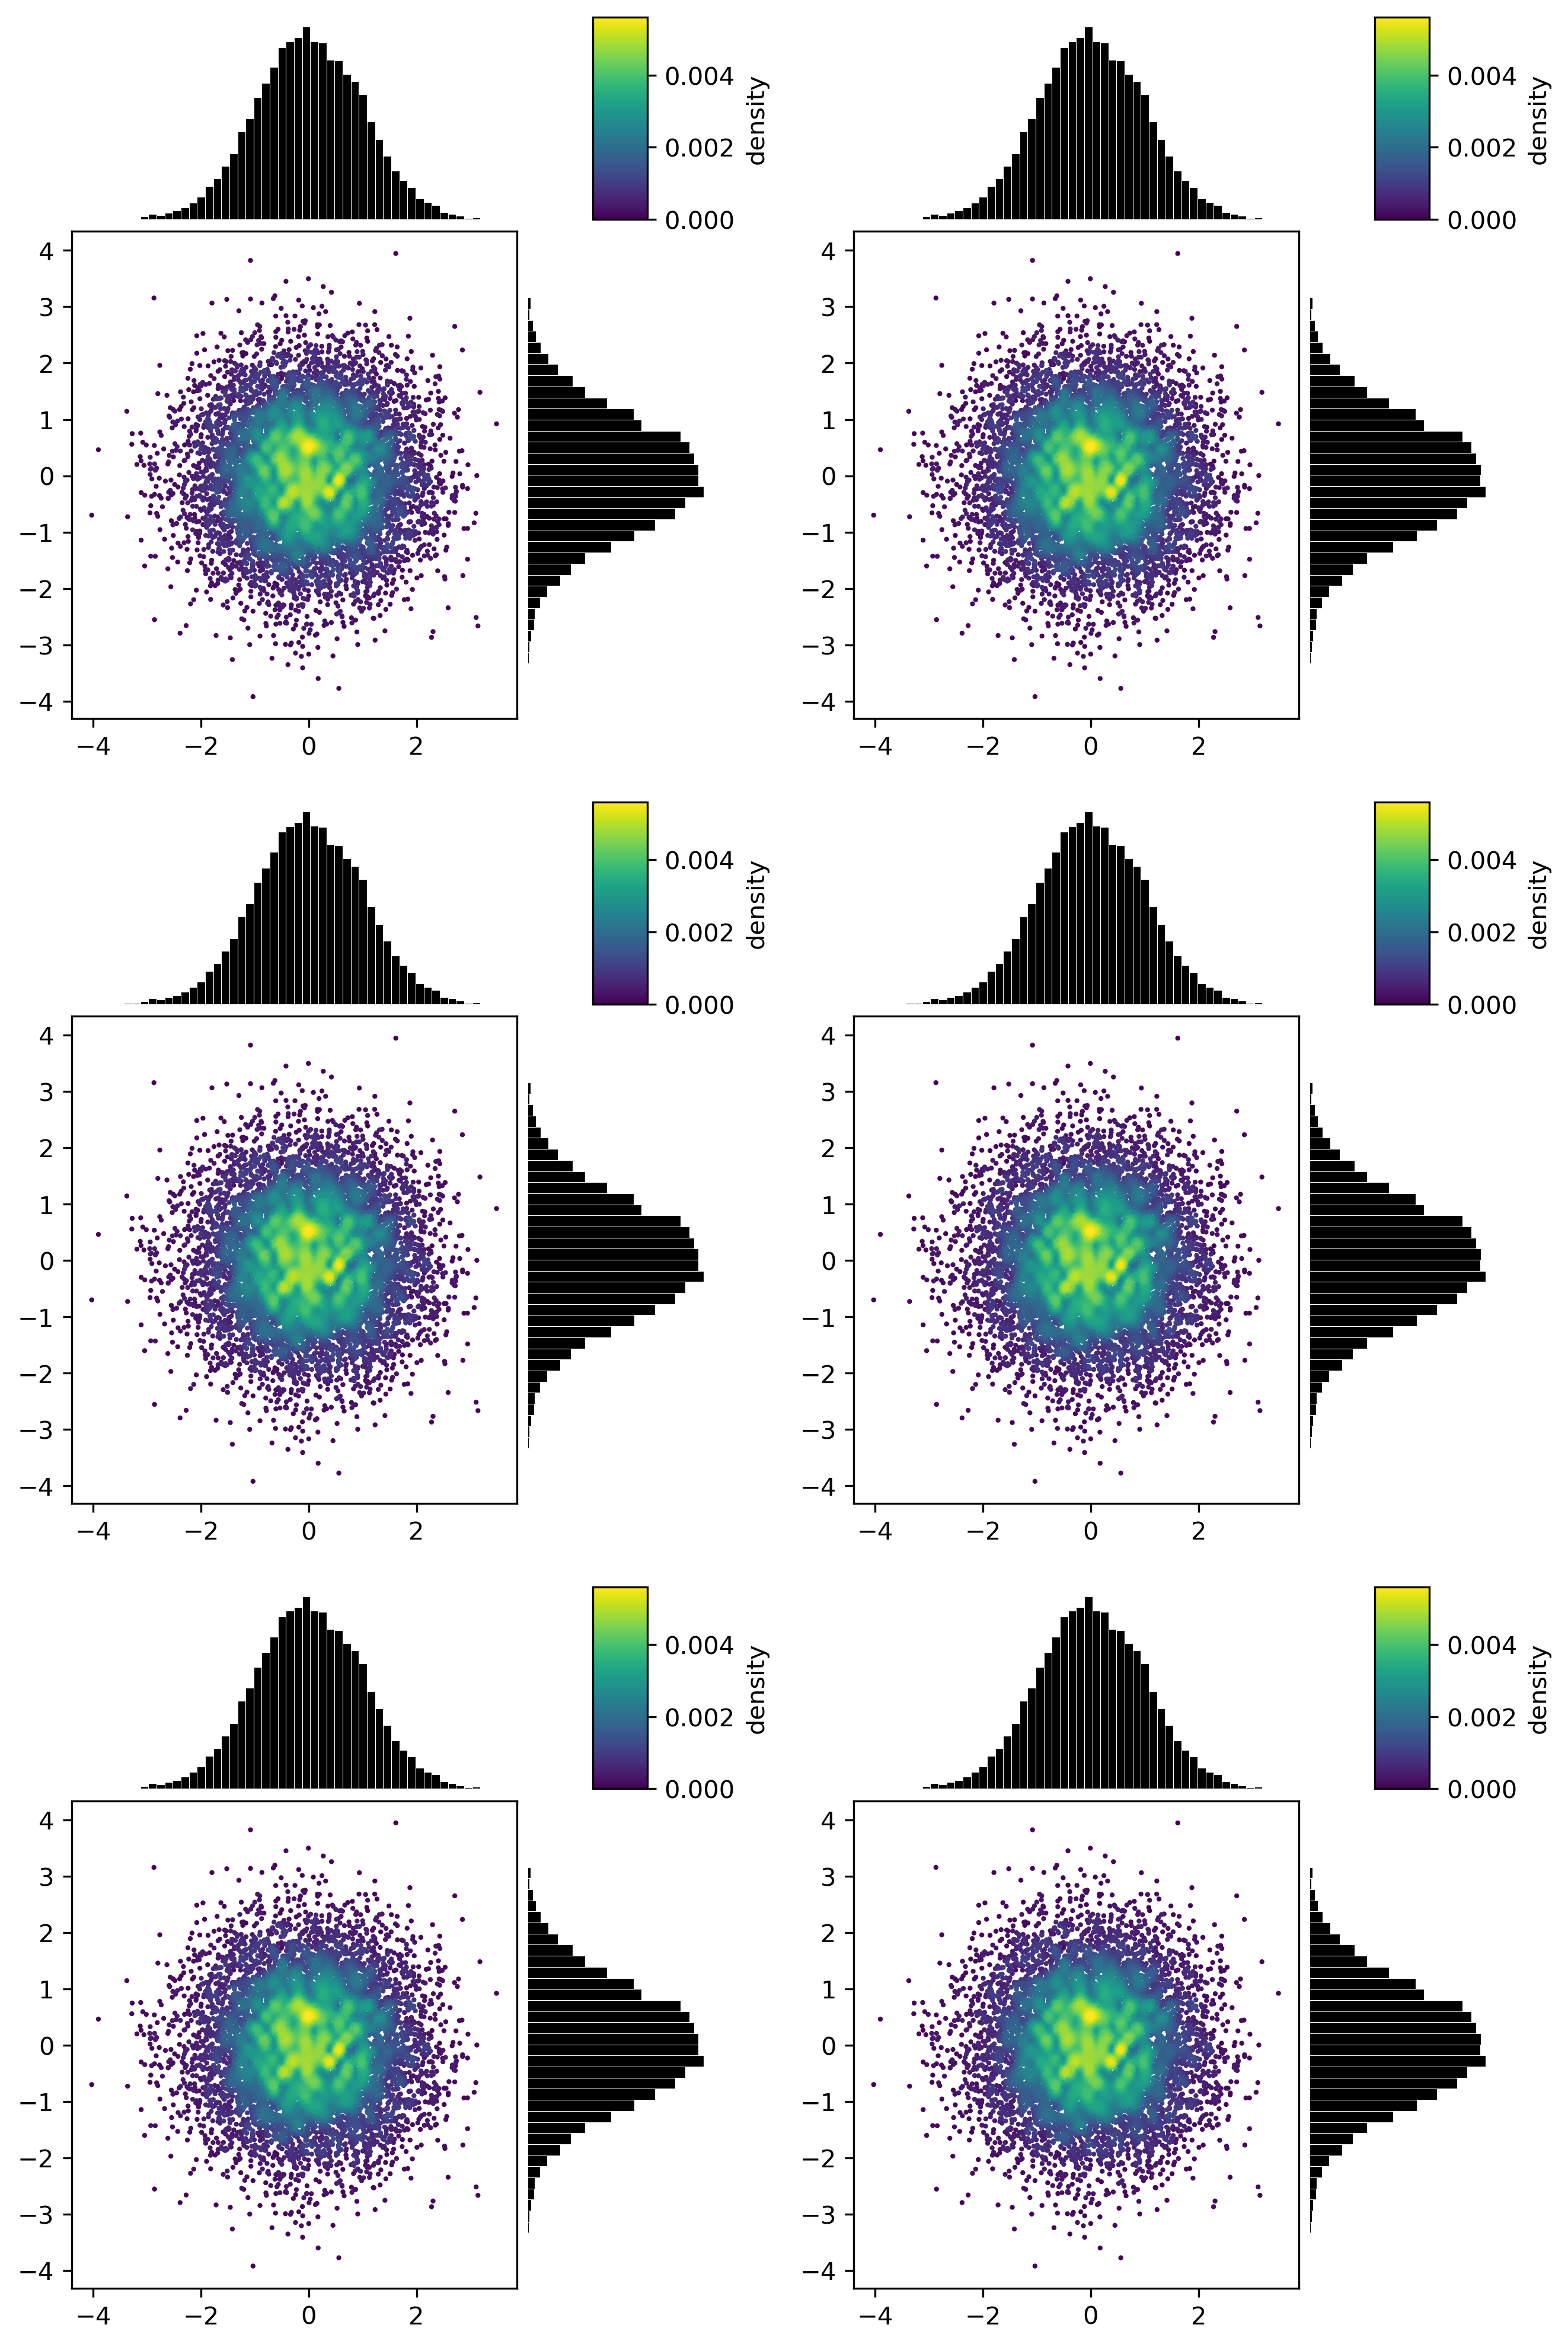

In [56]:
joint_plot_grid(xs, ys, nbins_x=50, nbins_y=40, log_norm=False, granularity=10, use_mpl_sd=False, s=1)

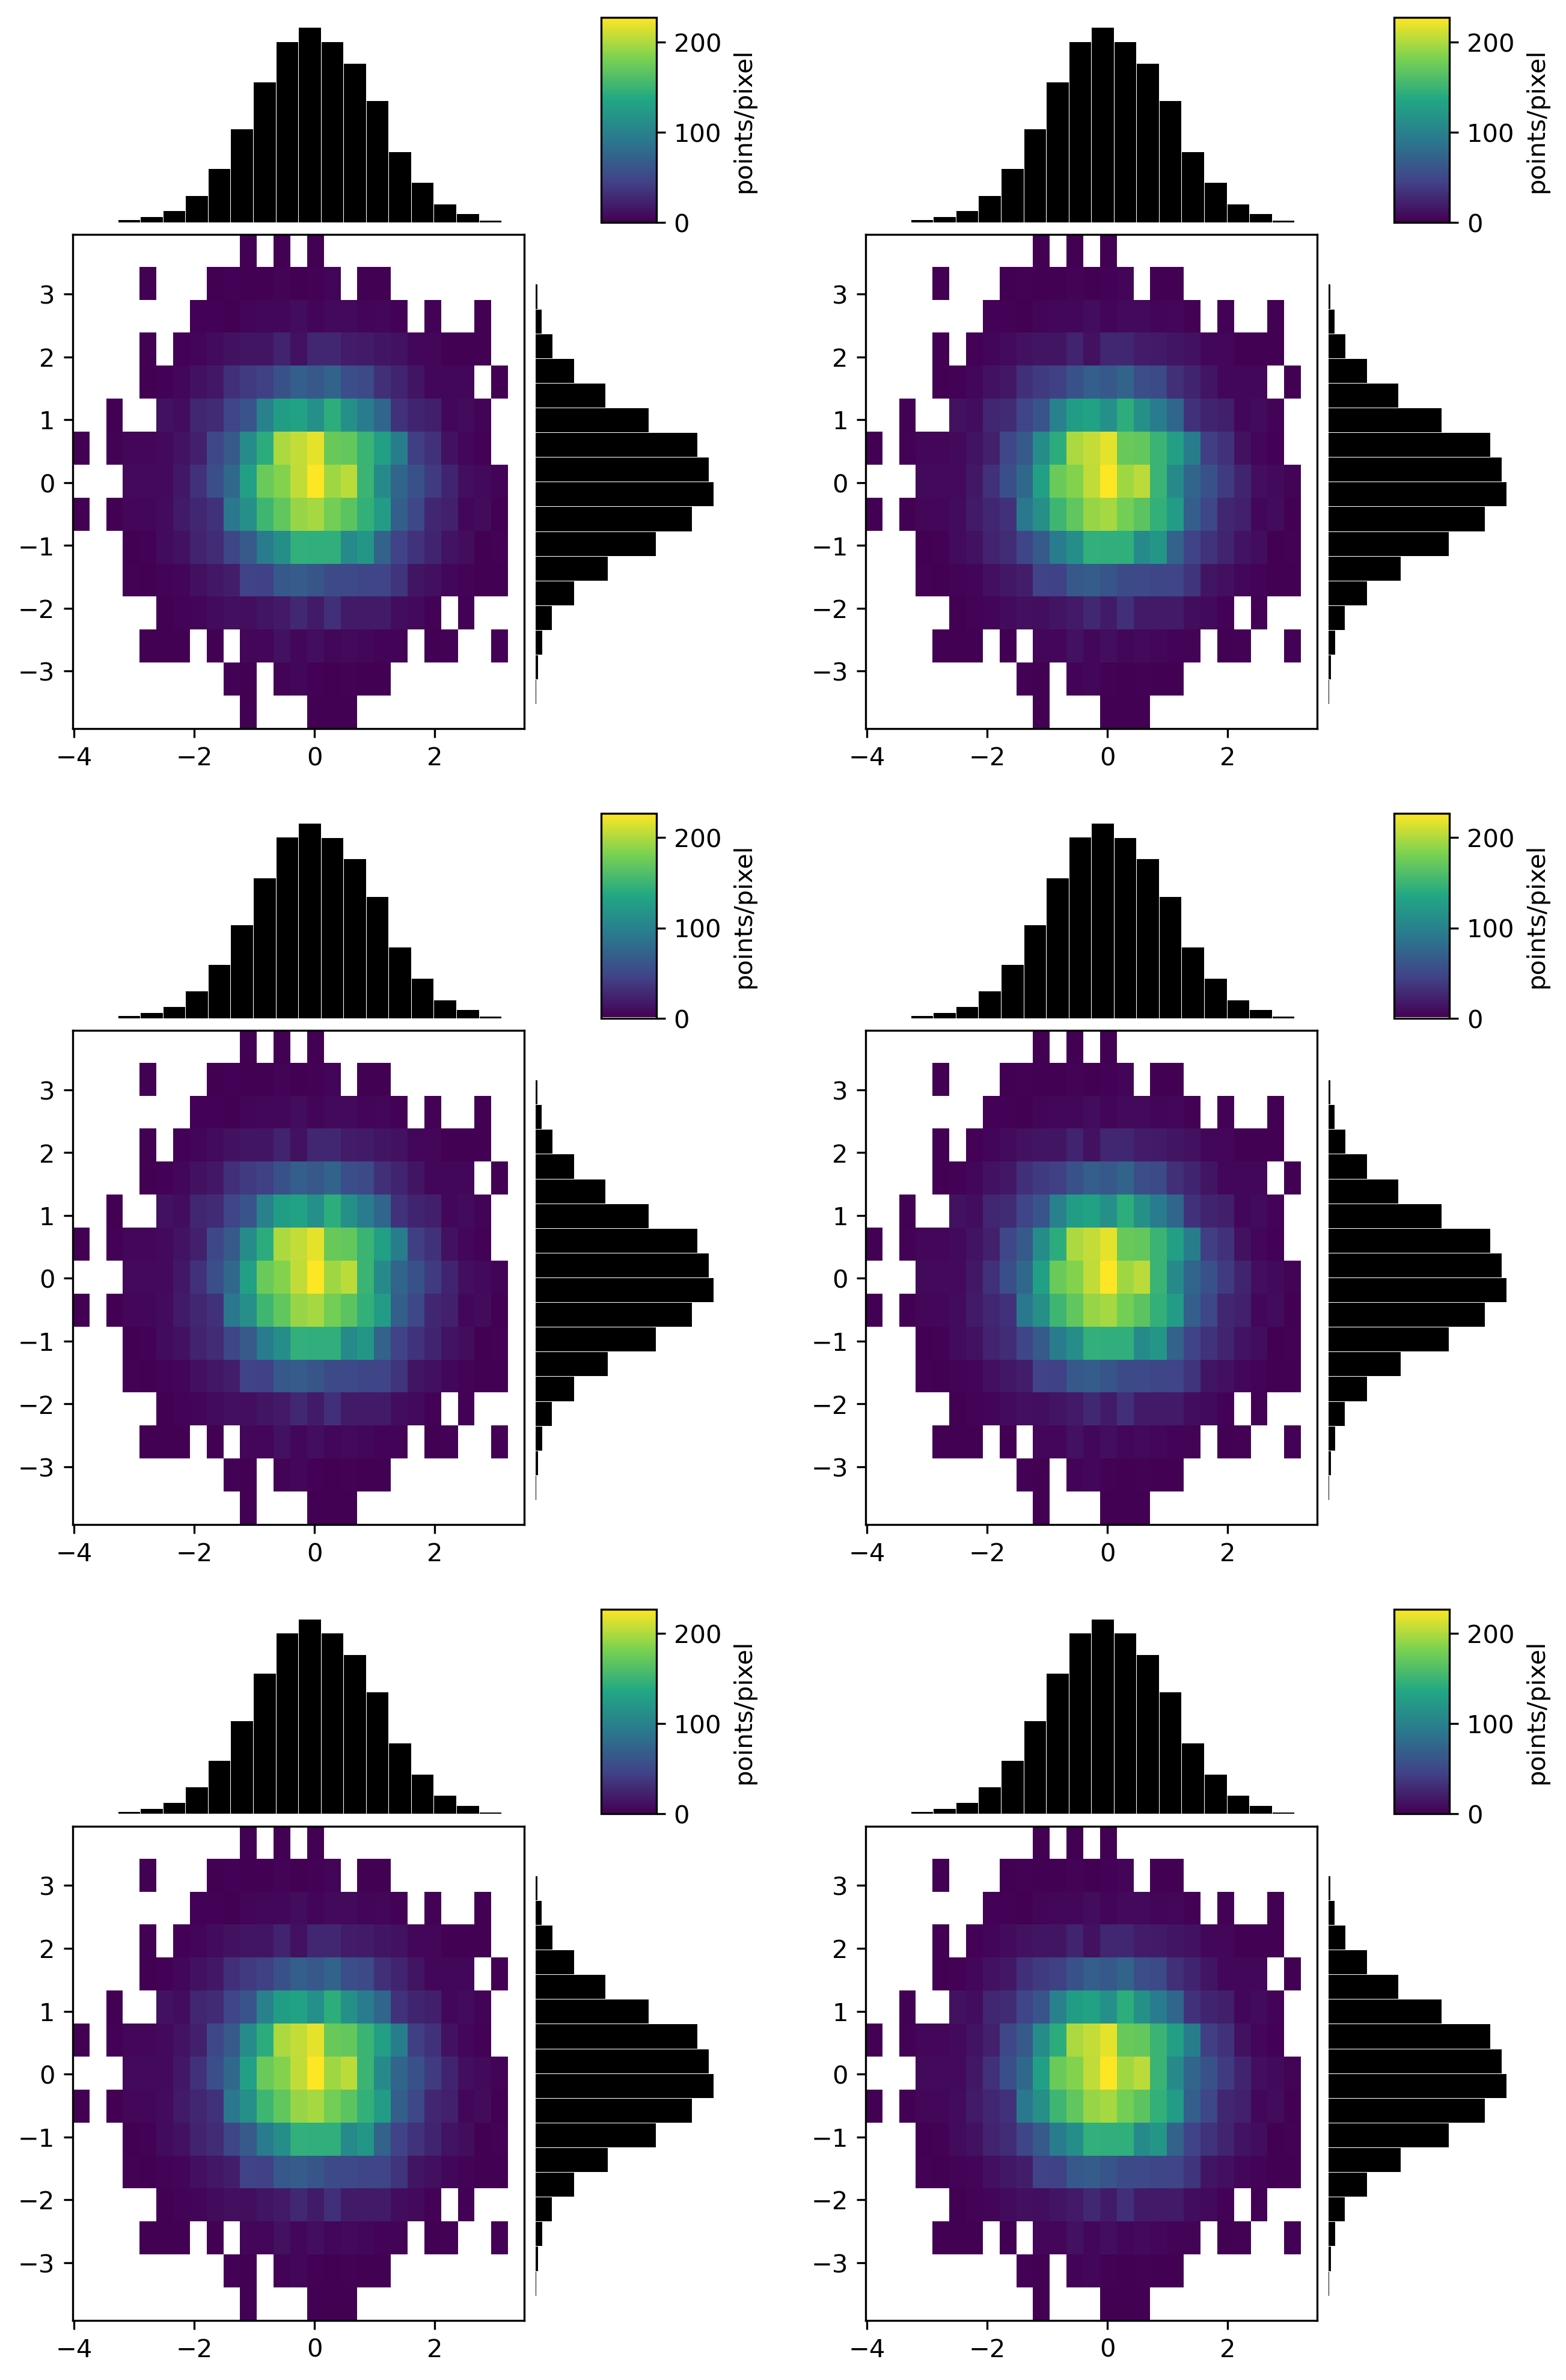

In [57]:
joint_plot_grid(xs, ys, granularity=10, use_mpl_sd=True)

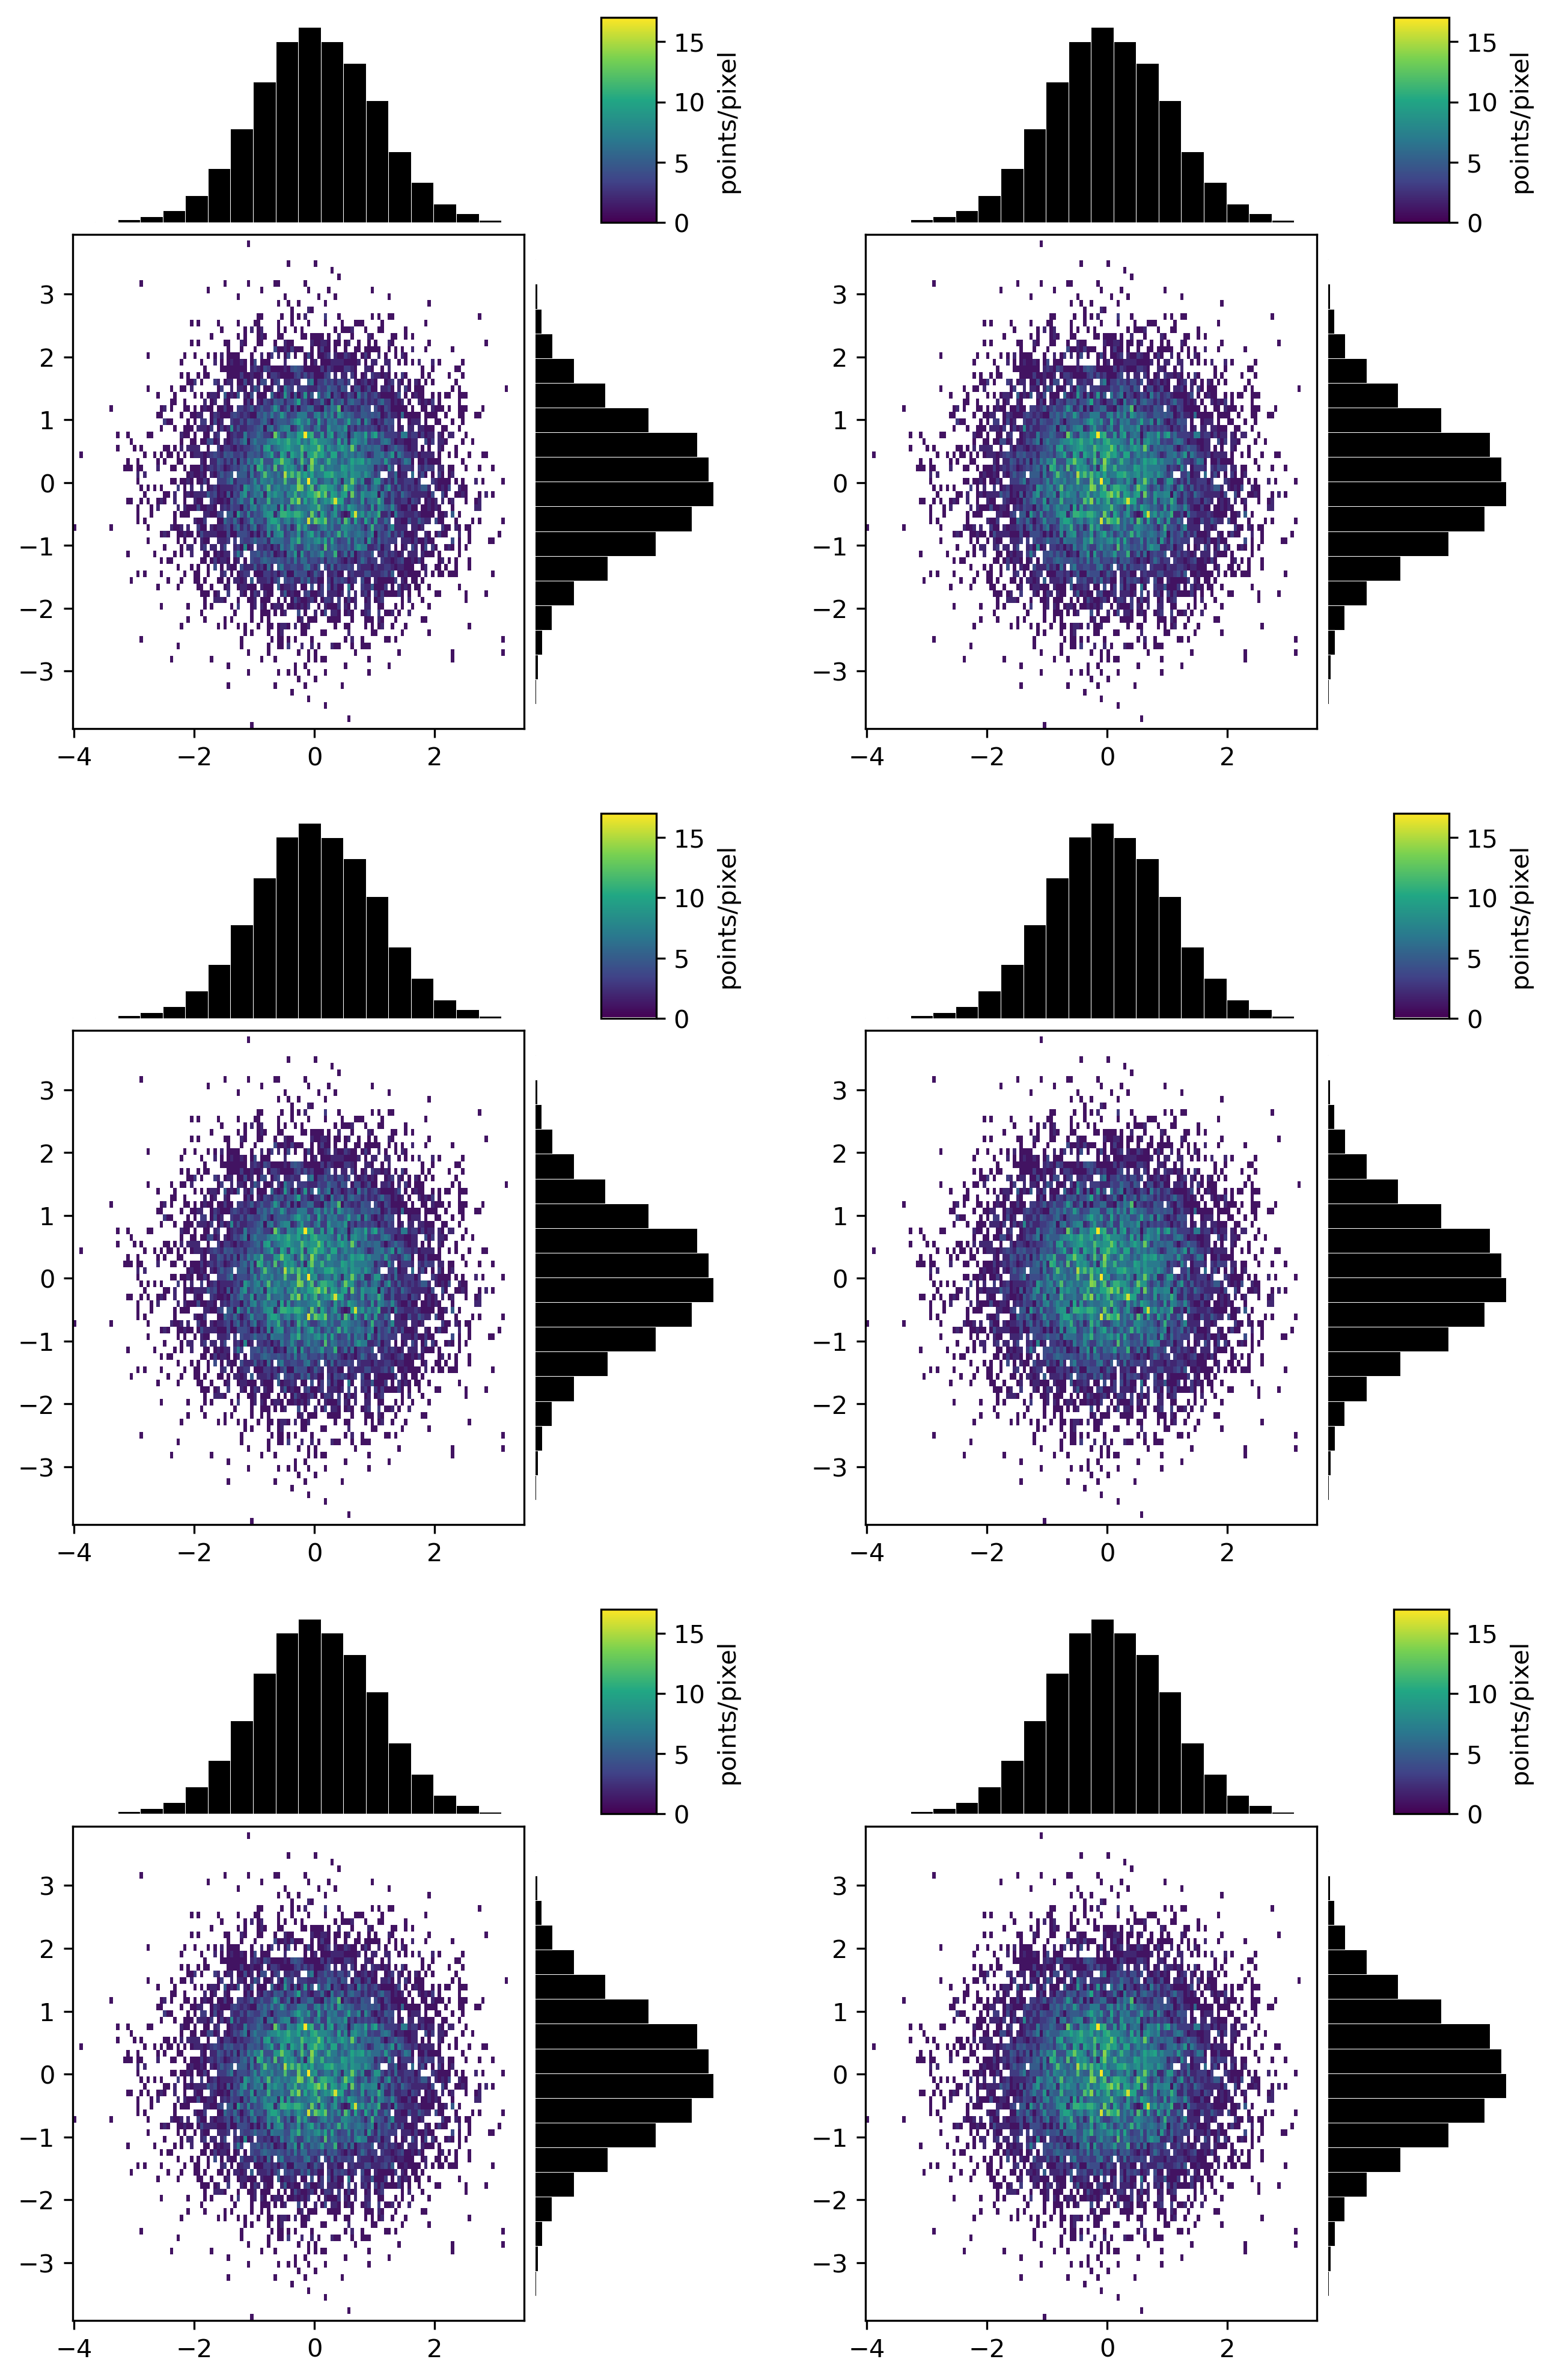

In [58]:
joint_plot_grid(xs, ys, granularity=50, use_mpl_sd=True)